In [1]:
import pandas as pd
import numpy as np

import re
import nltk
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("de.csv")

df.head()

,original_code,original_name,translated_name,HCAT3_name,HCAT3_code
0,48,Mischung Mais/Bohne,Corn / bean mixture,grain_maize_corn_popcorn,3301010600
1,49,Blühmischung für Biogas,Flowering mixture for biogas,flowers_ornamental_plants,3301080000
2,50,Mischkulturen mit Saatgutmischung,Mixed cultures with seed mix,arable_land_seed_seedlings,3301100000
3,51,Mischkulturen in Reihenanbau,Mixed crops in rows,other_arable_land_crops,3301990000
4,52,Zwischenfrucht / Gründecke ÖVF,Intercrop / groundcover,other_arable_land_crops,3301990000


In [4]:
print(df.columns)
print(df.head())

Index(['original_code', 'original_name', 'translated_name', 'HCAT3_name',
       'HCAT3_code'],
      dtype='str')
   original_code                      original_name  \
0             48                Mischung Mais/Bohne   
1             49            Blühmischung für Biogas   
2             50  Mischkulturen mit Saatgutmischung   
3             51       Mischkulturen in Reihenanbau   
4             52     Zwischenfrucht / Gründecke ÖVF   

                translated_name                  HCAT3_name  HCAT3_code  
0           Corn / bean mixture    grain_maize_corn_popcorn  3301010600  
1  Flowering mixture for biogas   flowers_ornamental_plants  3301080000  
2  Mixed cultures with seed mix  arable_land_seed_seedlings  3301100000  
3           Mixed crops in rows     other_arable_land_crops  3301990000  
4       Intercrop / groundcover     other_arable_land_crops  3301990000  


In [6]:
df.head()

,original_code,original_name,translated_name,HCAT3_name,HCAT3_code
0,48,Mischung Mais/Bohne,Corn / bean mixture,grain_maize_corn_popcorn,3301010600
1,49,Blühmischung für Biogas,Flowering mixture for biogas,flowers_ornamental_plants,3301080000
2,50,Mischkulturen mit Saatgutmischung,Mixed cultures with seed mix,arable_land_seed_seedlings,3301100000
3,51,Mischkulturen in Reihenanbau,Mixed crops in rows,other_arable_land_crops,3301990000
4,52,Zwischenfrucht / Gründecke ÖVF,Intercrop / groundcover,other_arable_land_crops,3301990000


In [9]:
print(df.columns.tolist())

['original_code', 'original_name', 'translated_name', 'HCAT3_name', 'HCAT3_code']


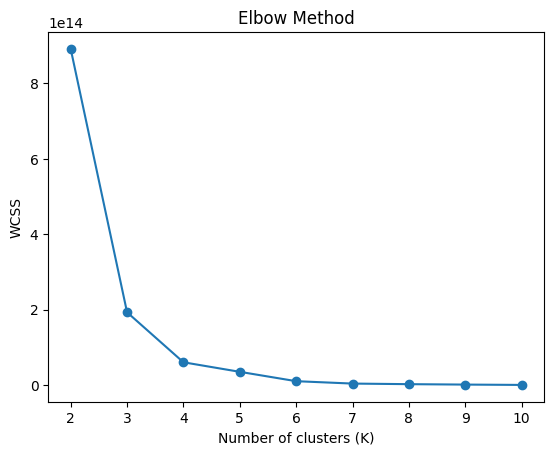

In [13]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pandas as pd

# Keep only numeric columns (fixes your error)
X = df.select_dtypes(include=['number']).values

wcss = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(2, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters (K)")
plt.ylabel("WCSS")
plt.show()

In [14]:
k = 4  # change based on elbow result

kmeans = KMeans(n_clusters=k, random_state=42)
df['cluster'] = kmeans.fit_predict(X)

In [15]:
df.head(10)

,original_code,original_name,translated_name,HCAT3_name,HCAT3_code,cluster
0,48,Mischung Mais/Bohne,Corn / bean mixture,grain_maize_corn_popcorn,3301010600,0
1,49,Blühmischung für Biogas,Flowering mixture for biogas,flowers_ornamental_plants,3301080000,0
2,50,Mischkulturen mit Saatgutmischung,Mixed cultures with seed mix,arable_land_seed_seedlings,3301100000,0
3,51,Mischkulturen in Reihenanbau,Mixed crops in rows,other_arable_land_crops,3301990000,0
4,52,Zwischenfrucht / Gründecke ÖVF,Intercrop / groundcover,other_arable_land_crops,3301990000,0
5,53,Untersaat ÖVF,Undersowing ÖVF,arable_land_seed_seedlings,3301100000,0
6,54,Streifen am Waldrand (Ohne Produktion) ÖVF,Strip at the edge of the forest (Without produ...,tree_wood_forest,3306000000,2
7,55,Ufervegetation ÖVF,Riparian vegetation,not_known_and_other,3399000000,1
8,56,ÖVF-Streifen AL,Ecological Preferance Area strips AL,not_known_and_other,3399000000,1
9,57,Feldrand / Pufferstreifen ÖVF DGL,Buffer strips ecological preference zones perm...,pasture_meadow_grassland_grass,3302000000,0


In [19]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.cluster import KMeans

# 1. Your data (REQUIRED)
texts = [
    "dog cat animal pet",
    "car bus train transport",
    "apple banana fruit food",
    "football soccer sport game",
    "python java programming code",
    "lion tiger wild animal",
    "truck vehicle road transport",
    "orange mango fruit healthy",
    "basketball nba sport league",
    "software development coding python"
]

# 2. Vectorize text
vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(texts)

# 3. Fit KMeans
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans.fit(X)

# 4. Get words
terms = vectorizer.get_feature_names_out()

# 5. Get top words per cluster
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

# 6. Print clusters
for i in range(k):
    print(f"\nCluster {i} top words:")
    top_words = [terms[ind] for ind in order_centroids[i, :10]]
    print(top_words)


Cluster 0 top words:
['animal', 'sport', 'fruit', 'mango', 'apple', 'banana', 'basketball', 'cat', 'dog', 'food']

Cluster 1 top words:
['python', 'code', 'software', 'development', 'coding', 'programming', 'java', 'car', 'cat', 'game']

Cluster 2 top words:
['transport', 'car', 'truck', 'train', 'vehicle', 'bus', 'road', 'coding', 'football', 'food']


In [20]:
pca = PCA(n_components=2)
reduced = pca.fit_transform(X.toarray())

In [21]:
df.to_csv("clustered_de.csv", index=False)